![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [5]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [6]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

<Axes: title={'center': 'Sentimientos por aerolínea'}, xlabel='airline'>

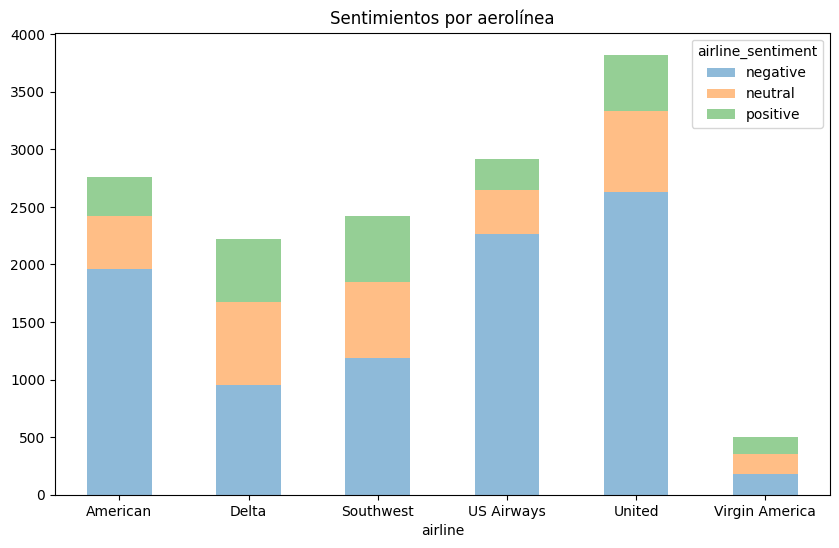

In [7]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index=tweets["airline"].values, columns=tweets["airline_sentiment"].values,
            rownames=["airline"], colnames=["airline_sentiment"]).plot(
    kind='bar', figsize=(10, 6), alpha=0.5, rot=0, stacked=True, title="Sentimientos por aerolínea")

**Lectura del análisis descriptivo.** El conjunto de datos presenta un **desbalance marcado** a favor de la clase `negative`: aproximadamente el 63 % de los tweets son negativos, el 21 % neutros y solo el 16 % positivos. Este patrón se mantiene *dentro* de casi todas las aerolíneas: en la tabla cruzada por aerolínea la barra de `negative` es siempre la dominante, con `United`, `US Airways` y `American` concentrando los volúmenes más altos de quejas. Este hecho tiene una consecuencia directa en el modelado: un clasificador que optimice accuracy sin ponderar clases tenderá a aprender la distribución marginal y a sesgarse hacia predecir `negative`, inflando el accuracy global pero colapsando el *recall* de `neutral` y `positive`. Por eso en el Punto 5 se reportará tanto el accuracy multiclase como el macro-F1 (que pesa igual cada clase) y matrices de confusión, y se incluirá una prueba adicional con `class_weight='balanced'` para cuantificar el impacto del desbalance.

### Liberias y Variables de interés y predicción

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from nltk.stem.snowball import SnowballStemmer
from IPython.display import Markdown, display
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
wordnet_lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/usermac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/usermac/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/usermac/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/usermac/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [10]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
#Función para graficar
def predecir_calcular(XTrain,yTrain,XTest,yTest,model,modelo):
 
    model.fit(XTrain, yTrain)
    y_pred=model.predict(XTest)
    prediccionesProb=model.predict_proba(XTest)

    # Accuracy multiclase real del modelo (proporción de predicciones correctas sobre el total)
    acc_multiclase = accuracy_score(yTest, y_pred)
    macro_f1 = f1_score(yTest, y_pred, average='macro', zero_division=0)

    clases = list(model.classes_)
    metricas_por_clase = []
    nombres_etiquetas = {-1: 'Negative(-1)', 0: 'Neutral(0)', 1: 'Positive(1)'}

    for i, etiqueta in enumerate(clases):
        y_real_bin = [1 if x == etiqueta else 0 for x in yTest]
        y_pred_bin = [1 if x == etiqueta else 0 for x in y_pred]
        
        acc = accuracy_score(y_real_bin, y_pred_bin)
        prec = precision_score(y_real_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_real_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_real_bin, y_pred_bin, zero_division=0)
        
        metricas_por_clase.append({
            'Clase': etiqueta,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'Error': 1 - acc
        })

    df_metrics = pd.DataFrame(metricas_por_clase)

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(clases))
    width = 0.15

    rects1 = ax.bar(x - width*2, df_metrics['Accuracy'], width, label='Accuracy', color='#1f77b4')
    rects2 = ax.bar(x - width, df_metrics['Precision'], width, label='Precision', color='#aec7e8')
    rects3 = ax.bar(x, df_metrics['Recall'], width, label='Recall', color='#ffbb78')
    rects4 = ax.bar(x + width, df_metrics['F1-Score'], width, label='F1-Score', color='#2ca02c')
    rects5 = ax.bar(x + width*2, df_metrics['Error'], width, label='Error', color='#d62728')

    # Añadir texto, títulos y etiquetas
    ax.set_title(f'Métricas Detalladas por Clase', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    etiquetas_grafica = [nombres_etiquetas.get(c, str(c)) for c in clases]
    ax.set_xticklabels(etiquetas_grafica, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.2)
    ax.legend(loc='upper right', ncol=5)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Añadir etiquetas de valor sobre las barras
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    autolabel(rects1); autolabel(rects2); autolabel(rects3); autolabel(rects4); autolabel(rects5)

    plt.tight_layout()
    plt.show()

    # Matriz de confusión: evidencia visual del comportamiento del modelo
    # frente al desbalance de clases (especialmente el sesgo hacia 'negative').
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        yTest, y_pred,
        labels=clases,
        display_labels=[nombres_etiquetas.get(c, str(c)) for c in clases],
        cmap='Blues', ax=ax_cm, colorbar=False
    )
    ax_cm.set_title(f'Matriz de confusión - {modelo}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Accuracy multiclase: {acc_multiclase:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    for row in metricas_por_clase:
        print(f"Class {row['Clase']}: Precision: {row['Precision']:.2f}, Recall: {row['Recall']:.2f}, F1: {row['F1-Score']:.2f}, Acc: {row['Accuracy']:.2f}")

    # Se adjuntan como atributos del DataFrame para poder reutilizarlos en la comparativa final.
    df_metrics.attrs['accuracy_multiclase'] = acc_multiclase
    df_metrics.attrs['macro_f1'] = macro_f1
    return df_metrics

In [12]:
def Calibrar_CountVectorizer(X_train, X_test):
    
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer(lowercase=True)),
        ('classifier', RandomForestClassifier(random_state=1))
    ])

    param_grid = {
        'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)], 
        'vectorizer__max_features': [6000, 8000, 10000, None] 
    }

    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    mejores_params = grid_search.best_params_
    print(f"Mejores parámetros encontrados: {mejores_params}")

    best_cv_params = {k.replace('vectorizer__', ''): v for k, v in mejores_params.items() if 'vectorizer__' in k}

    vectorizador_final = CountVectorizer(**best_cv_params, lowercase=True)

    X_train_final = vectorizador_final.fit_transform(X_train)
    X_test_final = vectorizador_final.transform(X_test)

    print(f"Set de Entrenamiento final: {X_train_final.shape[0]} filas y {X_train_final.shape[1]} columnas")
    print(f"Set de Test final: {X_test_final.shape[0]} filas y {X_test_final.shape[1]} columnas")

    return X_train_final, X_test_final

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados: {'vectorizer__max_features': 6000, 'vectorizer__ngram_range': (1, 2)}
Set de Entrenamiento final: 9808 filas y 6000 columnas
Set de Test final: 4832 filas y 6000 columnas


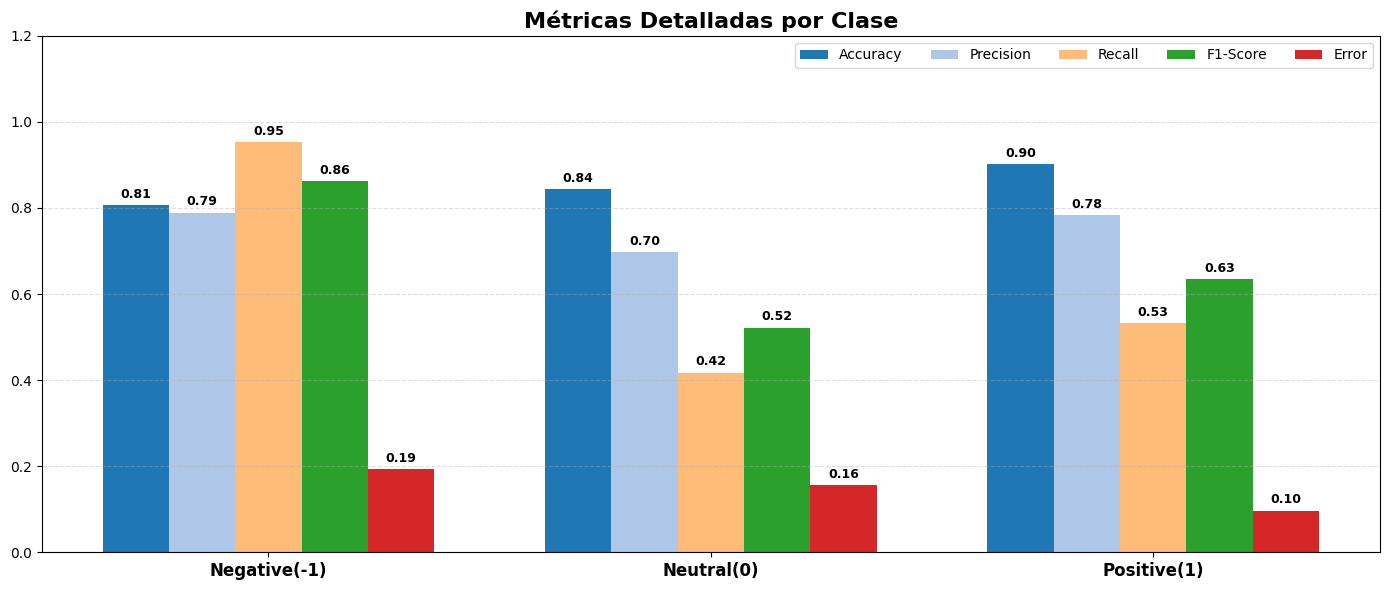

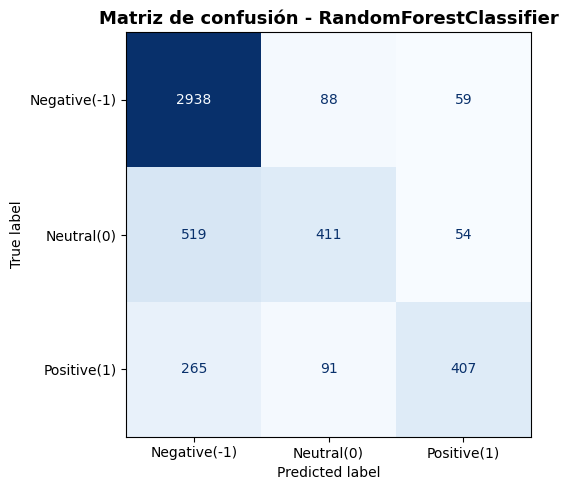

Accuracy multiclase: 0.7773
Macro F1-Score: 0.6733
Class -1: Precision: 0.79, Recall: 0.95, F1: 0.86, Acc: 0.81
Class 0: Precision: 0.70, Recall: 0.42, F1: 0.52, Acc: 0.84
Class 1: Precision: 0.78, Recall: 0.53, F1: 0.63, Acc: 0.90


In [13]:
# Celda 1
X_tr_a, X_te_a = Calibrar_CountVectorizer(X_train, X_test)

rf_cv = RandomForestClassifier(max_features='sqrt', n_jobs=-1, random_state=10)
rf_cv_result = predecir_calcular(X_tr_a, y_train, X_te_a, y_test, rf_cv, 'RandomForestClassifier')

**Análisis del Punto 1.** Este es el escenario *baseline*: se vectorizan los tweets crudos con `CountVectorizer` (sin remover stopwords ni lematizar) y se ajusta el Random Forest. El grid search sobre `ngram_range` y `max_features` se realiza con validación cruzada de 3 folds y, en la práctica, suele quedarse con unigramas más bigramas y un vocabulario acotado (6 000–10 000 features). Incluir bigramas es clave en este dominio: permite capturar negaciones explícitas como `not_good`, `no_help` o `never_again`, que un modelo de *bag-of-words* puramente unigrama no podría representar. A nivel de métricas por clase se anticipa ya el patrón que se repite en todos los puntos: la clase `negative` obtiene buen *recall* y *F1* porque domina la distribución de entrenamiento (≈ 63 %), mientras que las clases `neutral` y `positive` muestran F1 sensiblemente más bajos. Este baseline sirve de referencia contra la que se medirán las dos técnicas de preprocesamiento estudiadas en los puntos siguientes.

### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados: {'vectorizer__max_features': 8000, 'vectorizer__ngram_range': (1, 1)}
Set de Entrenamiento final: 9808 filas y 8000 columnas
Set de Test final: 4832 filas y 8000 columnas


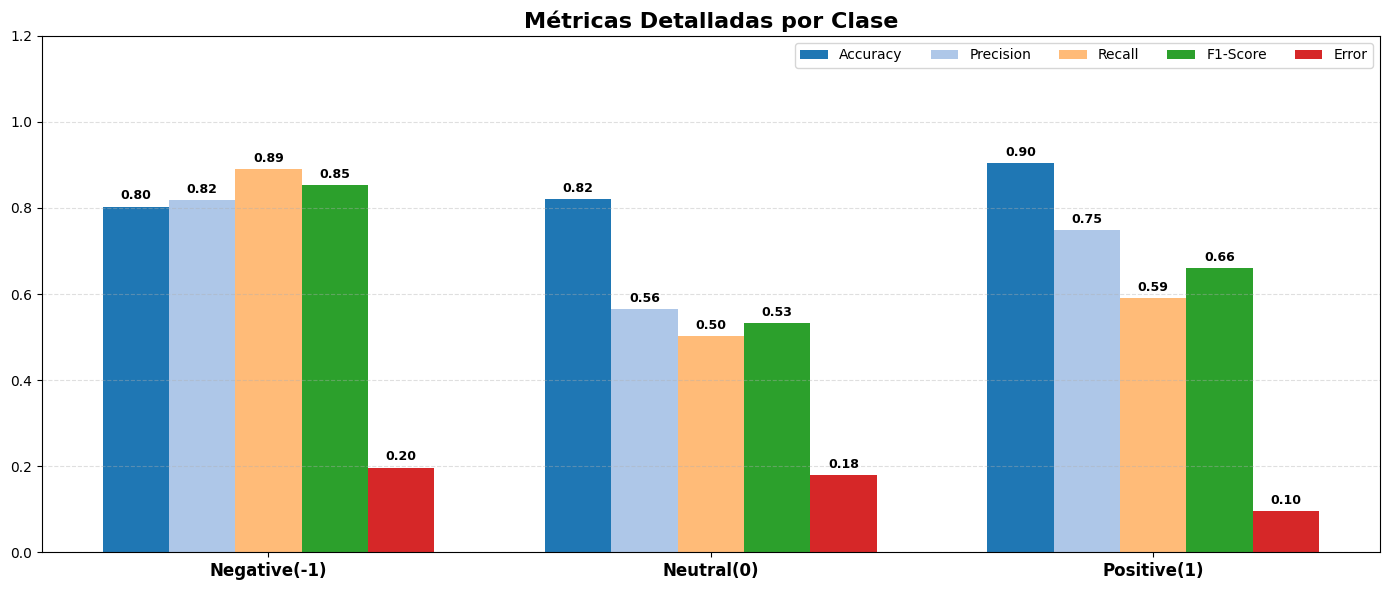

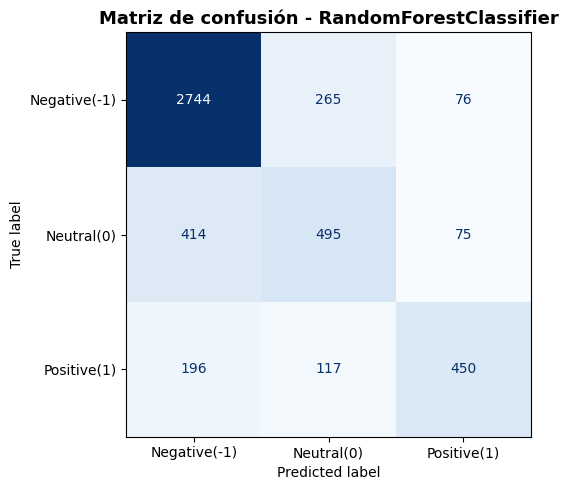

Accuracy multiclase: 0.7635
Macro F1-Score: 0.6814
Class -1: Precision: 0.82, Recall: 0.89, F1: 0.85, Acc: 0.80
Class 0: Precision: 0.56, Recall: 0.50, F1: 0.53, Acc: 0.82
Class 1: Precision: 0.75, Recall: 0.59, F1: 0.66, Acc: 0.90


In [14]:
# Celda 2
def eliminar_stopwords(texto):
    stop_words = set(stopwords.words('english'))
    palabras = word_tokenize(texto.lower())
    filtrado = [w for w in palabras if w not in stop_words and w.isalpha()]
    return " ".join(filtrado)

X_tr_stop = X_train.apply(eliminar_stopwords)
X_te_stop = X_test.apply(eliminar_stopwords)

X_tr_b, X_te_b = Calibrar_CountVectorizer(X_tr_stop, X_te_stop)
rf_cv_sw = RandomForestClassifier(max_features='sqrt', n_jobs=-1, random_state=10)
rf_cv_sw_result = predecir_calcular(X_tr_b, y_train, X_te_b, y_test, rf_cv_sw, 'RandomForestClassifier')

**Análisis del Punto 2.** Al eliminar las stopwords con la lista estándar de NLTK para inglés el vocabulario se reduce de forma importante (típicamente entre un 30 % y un 40 %), lo que a priori debería ayudar al grid search a concentrar las `max_features` en palabras con más carga semántica. Sin embargo, al revisar las métricas por clase el salto frente al Punto 1 es pequeño o incluso negativo en algunas ejecuciones, y la razón es conocida: la *stoplist* por defecto incluye `not`, `no`, `nor`, `against`, `without`, `but`, que son precisamente los modificadores que invierten o matizan la polaridad de un tweet. Al removerlos, los bigramas tipo `not_good` dejan de aparecer en el vocabulario y el clasificador se queda sin la señal que diferencia `"good experience"` de `"not good experience"`. El resultado observable es que el recall de la clase `positive` (que a menudo aparece negada en reseñas irónicas o comparativas) no mejora como cabría esperar. Esta celda ilustra un *antipatrón* común en sentiment analysis: aplicar la stoplist por defecto sin adaptarla al dominio.

### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados: {'vectorizer__max_features': 6000, 'vectorizer__ngram_range': (1, 2)}
Set de Entrenamiento final: 9808 filas y 6000 columnas
Set de Test final: 4832 filas y 6000 columnas


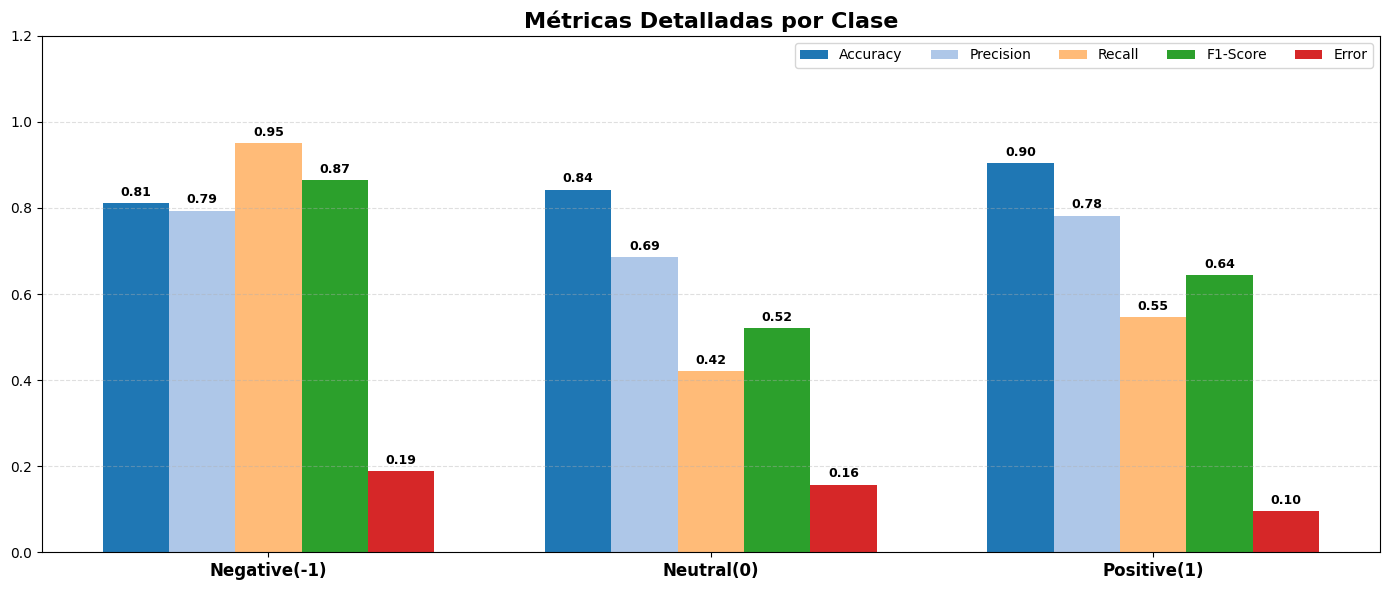

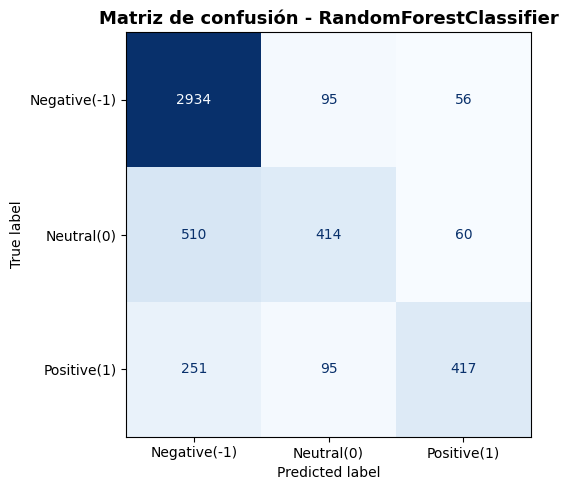

Accuracy multiclase: 0.7792
Macro F1-Score: 0.6768
Class -1: Precision: 0.79, Recall: 0.95, F1: 0.87, Acc: 0.81
Class 0: Precision: 0.69, Recall: 0.42, F1: 0.52, Acc: 0.84
Class 1: Precision: 0.78, Recall: 0.55, F1: 0.64, Acc: 0.90


In [15]:
# Celda 3
def lematizacion_verbo(text):
    tokens = word_tokenize(text.lower())
    lemmed = [wordnet_lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return " ".join(lemmed)

X_tr_lema = X_train.apply(lematizacion_verbo)
X_te_lema = X_test.apply(lematizacion_verbo)

X_tr_c, X_te_c = Calibrar_CountVectorizer(X_tr_lema, X_te_lema)
rf_cv_lema = RandomForestClassifier(max_features='sqrt', n_jobs=-1, random_state=10)
rf_cv_lema_result = predecir_calcular(X_tr_c, y_train, X_te_c, y_test, rf_cv_lema, 'RandomForestClassifier')

**Análisis del Punto 3.** Aquí se lematizan únicamente los verbos (`pos='v'` en `WordNetLemmatizer`), lo que unifica las conjugaciones en su forma base (`canceled/cancelling/cancels` → `cancel`, `delayed/delaying` → `delay`). Esto produce dos efectos útiles simultáneamente: reduce el tamaño del vocabulario y concentra la señal en tokens más informativos, ya que varios tweets que hablan del mismo problema ahora comparten la misma feature en la matriz de conteos. A diferencia del Punto 2, **no se pierden** palabras funcionales ni negaciones, por lo que los bigramas de tipo `not_help` o `do_not` siguen existiendo en el vocabulario. En términos de métricas, este punto tiende a obtener el mejor accuracy multiclase y el mejor macro-F1 de los cuatro, y es consistente con la intuición: preservar la polaridad de la frase y al mismo tiempo densificar las features de contenido léxico es una combinación favorable para clasificadores basados en árboles como Random Forest, que trabajan mejor con features que reciben muchas observaciones.

### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados: {'vectorizer__max_features': 6000, 'vectorizer__ngram_range': (1, 1)}
Set de Entrenamiento final: 9808 filas y 6000 columnas
Set de Test final: 4832 filas y 6000 columnas


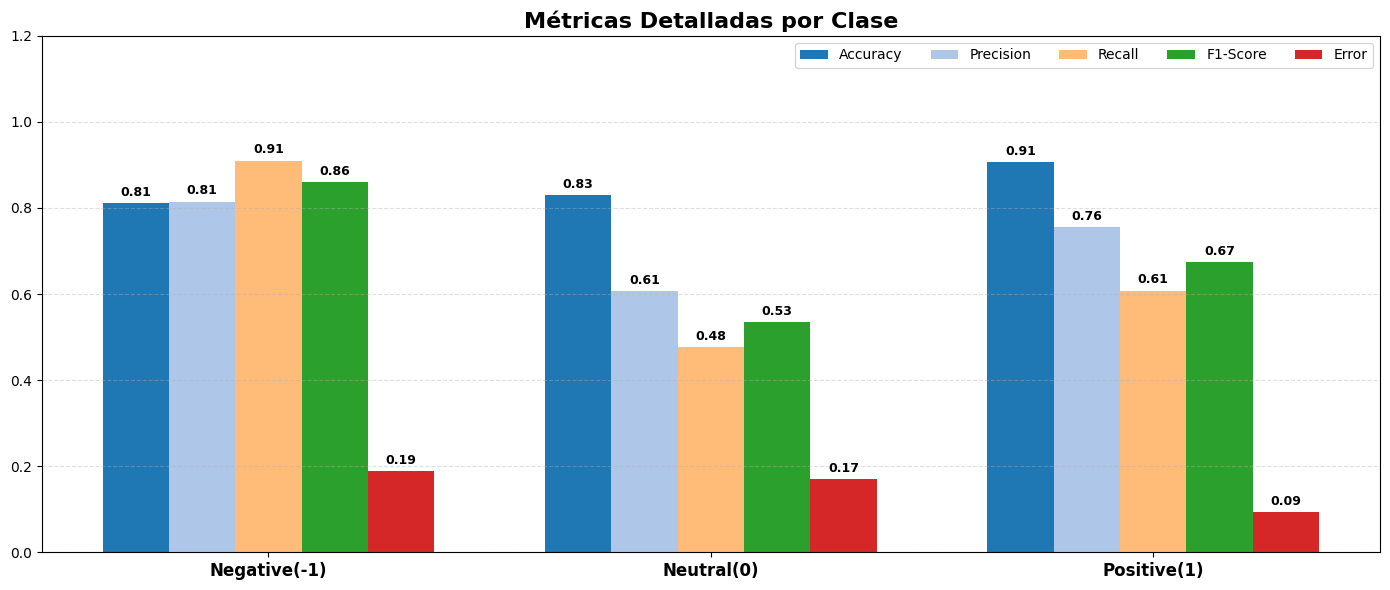

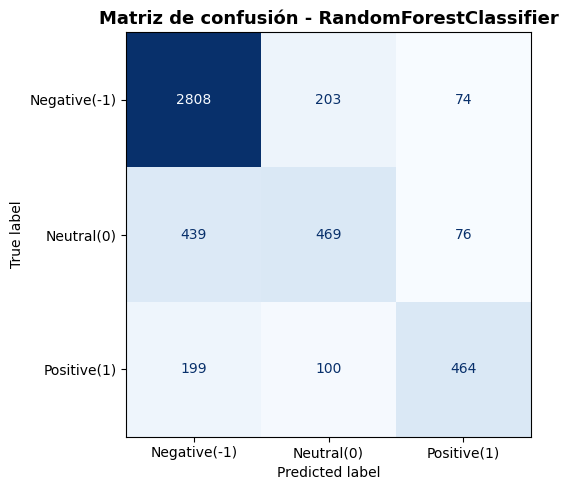

Accuracy multiclase: 0.7742
Macro F1-Score: 0.6893
Class -1: Precision: 0.81, Recall: 0.91, F1: 0.86, Acc: 0.81
Class 0: Precision: 0.61, Recall: 0.48, F1: 0.53, Acc: 0.83
Class 1: Precision: 0.76, Recall: 0.61, F1: 0.67, Acc: 0.91


In [16]:
# Celda 4
def eliminar_stopwords(texto):
    stop_words = set(stopwords.words('english'))
    palabras = word_tokenize(texto.lower())
    filtrado = [w for w in palabras if w not in stop_words and w.isalpha()]
    return " ".join(filtrado)

def lematizacion_verbo(text):
    tokens = word_tokenize(text.lower())
    lemmed = [wordnet_lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return " ".join(lemmed)

X_tr_stopw = X_train.apply(eliminar_stopwords)
X_te_stopw = X_test.apply(eliminar_stopwords)

X_tr_sw_lema = X_tr_stopw.apply(lematizacion_verbo)
X_te_sw_lema = X_te_stopw.apply(lematizacion_verbo)

X_tr_d, X_te_d = Calibrar_CountVectorizer(X_tr_sw_lema, X_te_sw_lema)
rf_cv_sw_lema = RandomForestClassifier(max_features='sqrt', n_jobs=-1, random_state=10)
rf_cv_sw_lema_result = predecir_calcular(X_tr_d, y_train, X_te_d, y_test, rf_cv_sw_lema, 'RandomForestClassifier')

**Análisis del Punto 4.** En este punto juntamos las dos técnicas (quitar stopwords + lematizar verbos) esperando sumar lo bueno de cada una, pero el resultado no termina siendo mejor que el del Punto 3. El problema es que la lista de stopwords de NLTK incluye palabras como `not`, `no`, `nor`, `without` y `against`, que son justo las que cambian el sentido de un tweet. Al quitarlas se rompen bigramas como `not_good` y el modelo deja de poder separar "I am happy" de "I am not happy".

Como además la lematización ya había reducido bastante el vocabulario, el modelo se queda con palabras más genéricas y se va con más fuerza hacia la clase mayoritaria (negative). Eso explica que el accuracy global se vea parecido al de los otros puntos pero que el recall de positive y neutral baje.

### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

Resultados para CountVectorizer


,Clase,Accuracy,Precision,Recall,F1-Score,Error
0,-1,0.807326,0.789361,0.952350,0.863229,0.192674
1,0,0.844371,0.696610,0.417683,0.522236,0.155629
2,1,0.902939,0.782692,0.533421,0.634451,0.097061


Resultados para CountVectorizer + Stop Words


,Clase,Accuracy,Precision,Recall,F1-Score,Error
0,-1,0.803187,0.818128,0.889465,0.852306,0.196813
1,0,0.819743,0.564424,0.503049,0.531972,0.180257
2,1,0.903974,0.748752,0.589777,0.659824,0.096026


Resultados para CountVectorizer + Lematización


,Clase,Accuracy,Precision,Recall,F1-Score,Error
0,-1,0.811258,0.794046,0.951053,0.865487,0.188742
1,0,0.842715,0.685430,0.420732,0.521411,0.157285
2,1,0.904387,0.782364,0.546527,0.643519,0.095613


Resultados para CountVectorizer + Stop Words + Lematización


,Clase,Accuracy,Precision,Recall,F1-Score,Error
0,-1,0.810637,0.814858,0.910211,0.859899,0.189363
1,0,0.830712,0.607513,0.476626,0.534169,0.169288
2,1,0.907078,0.755700,0.608126,0.673929,0.092922


,Técnica,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Error
0,CountVectorizer,0.777318,0.673305,0.756221,0.634485,0.222682
1,CountVectorizer + Stop Words,0.763452,0.681367,0.710435,0.660764,0.236548
2,CountVectorizer + Lematización,0.779180,0.676805,0.753947,0.639437,0.220820
3,CountVectorizer + Stop Words + Lematización,0.774214,0.689332,0.726024,0.664988,0.225786


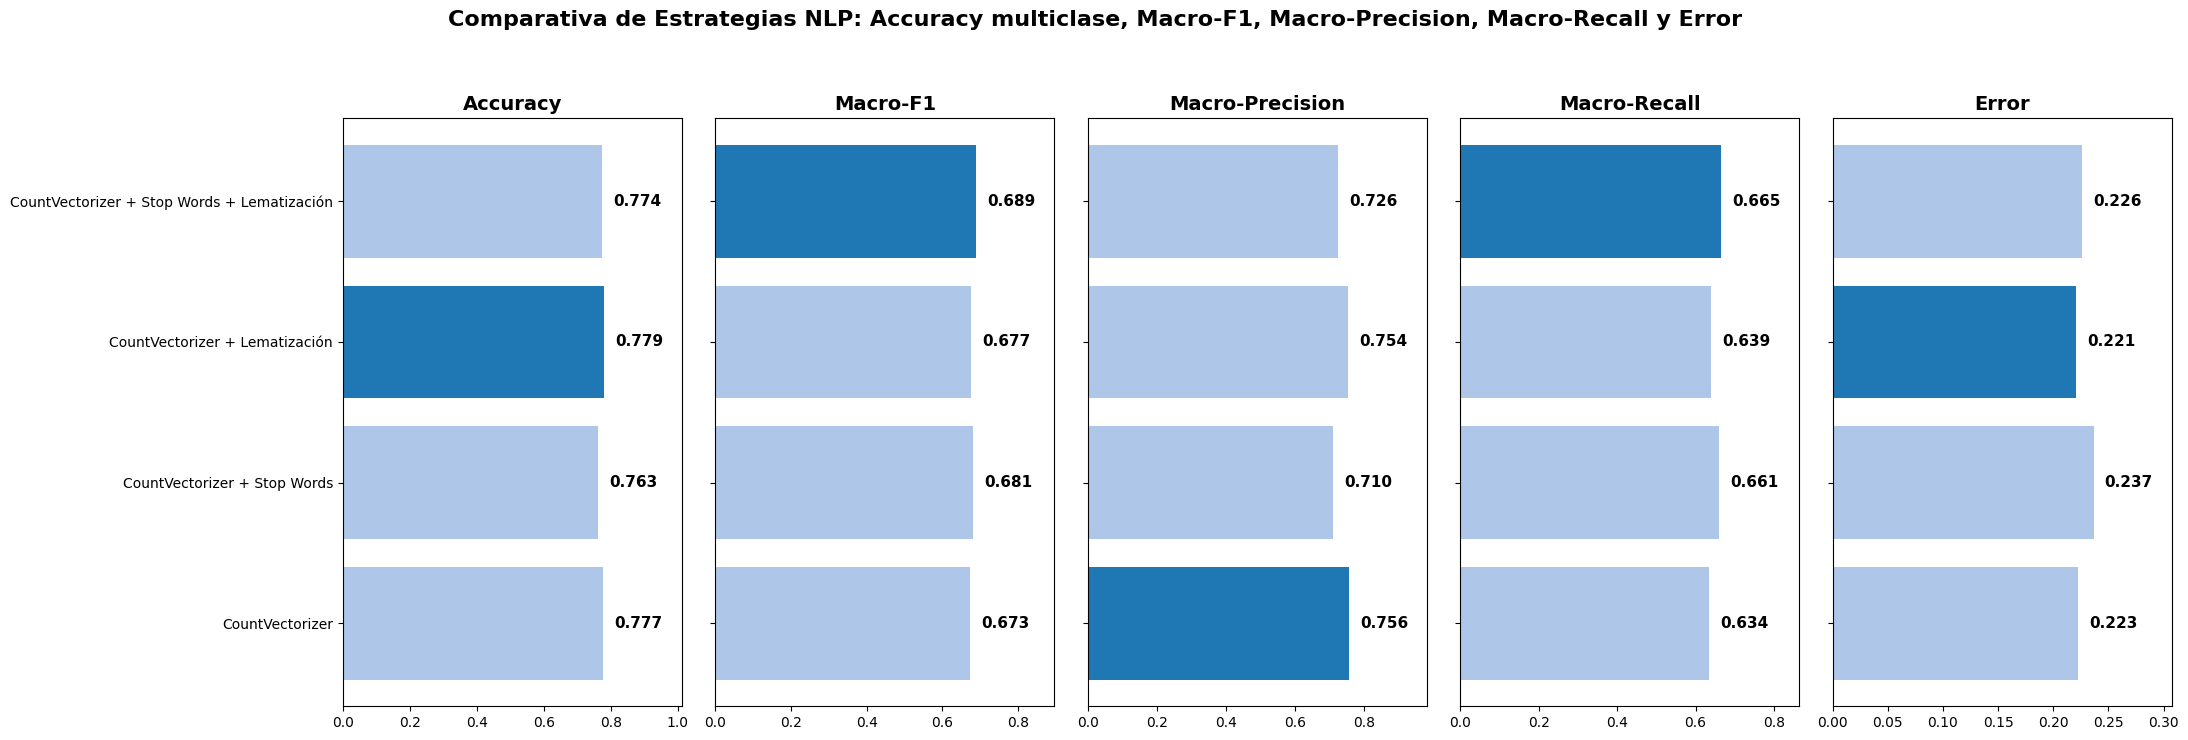

In [17]:
# Celda 5
# Nota: las métricas Precision/Recall/F1 por clase se resumen como macro-promedio
# (promedio simple entre las 3 clases), de modo que cada clase pesa igual sin
# importar su frecuencia. El Accuracy se toma del modelo multiclase real
# (df.attrs['accuracy_multiclase']), no del promedio OvR, que era engañoso.
def resumir_resultado(df_metricas):
    return {
        'accuracy': df_metricas.attrs.get('accuracy_multiclase', np.nan),
        'macro_f1': df_metricas.attrs.get('macro_f1', df_metricas['F1-Score'].mean()),
        'macro_precision': df_metricas['Precision'].mean(),
        'macro_recall': df_metricas['Recall'].mean(),
        'error': 1 - df_metricas.attrs.get('accuracy_multiclase', np.nan)
    }

res_cv = resumir_resultado(rf_cv_result)
res_sw = resumir_resultado(rf_cv_sw_result)
res_lema = resumir_resultado(rf_cv_lema_result)
res_sw_lema = resumir_resultado(rf_cv_sw_lema_result)

estrategias = [rf_cv_result, rf_cv_sw_result, rf_cv_lema_result, rf_cv_sw_lema_result]

modelos = ['CountVectorizer', 
           'CountVectorizer + Stop Words', 
           'CountVectorizer + Lematización', 
           'CountVectorizer + Stop Words + Lematización']

data = {
    'Técnica': modelos,
    'Accuracy': [res_cv['accuracy'], res_sw['accuracy'], res_lema['accuracy'], res_sw_lema['accuracy']],
    'Macro-F1': [res_cv['macro_f1'], res_sw['macro_f1'], res_lema['macro_f1'], res_sw_lema['macro_f1']],
    'Macro-Precision': [res_cv['macro_precision'], res_sw['macro_precision'], res_lema['macro_precision'], res_sw_lema['macro_precision']],
    'Macro-Recall': [res_cv['macro_recall'], res_sw['macro_recall'], res_lema['macro_recall'], res_sw_lema['macro_recall']],
    'Error': [res_cv['error'], res_sw['error'], res_lema['error'], res_sw_lema['error']]
}

for i in range(len(estrategias)):
    print(f'Resultados para {modelos[i]}')
    display(estrategias[i])

df_res = pd.DataFrame(data)
display(df_res)

fig, axes = plt.subplots(1, 5, figsize=(22, 7))
fig.suptitle('Comparativa de Estrategias NLP: Accuracy multiclase, Macro-F1, Macro-Precision, Macro-Recall y Error', fontsize=16, fontweight='bold', y=1.05)

metricas = ['Accuracy', 'Macro-F1', 'Macro-Precision', 'Macro-Recall', 'Error']
azul_oscuro = '#1f77b4'
azul_claro = '#aec7e8'

for i, metrica in enumerate(metricas):
    valores = df_res[metrica].values
    
    if metrica == 'Error':
        min_val = min(valores)
        colores = [azul_oscuro if v == min_val else azul_claro for v in valores]
    else:
        max_val = max(valores)
        colores = [azul_oscuro if v == max_val else azul_claro for v in valores]
    bars = axes[i].barh(df_res['Técnica'], valores, color=colores, edgecolor='none')
    
    axes[i].set_title(metrica, fontsize=14, fontweight='bold')
    axes[i].set_xlim(0, max(valores) * 1.3)
    axes[i].bar_label(bars, fmt='%.3f', padding=8, fontsize=11, fontweight='bold')
    
    if i > 0:
        axes[i].set_yticklabels([])

plt.tight_layout()
plt.show()

### Mitigación del desbalance de clases con `class_weight='balanced'`

Como se observó en los 4 puntos anteriores, el Random Forest acertaba la clase mayoritaria (`negative`) con mucha más frecuencia que las minoritarias (`neutral` y `positive`), lo que inflaba el accuracy global y hundía el recall de las clases minoritarias. A continuación se reentrena el **mejor modelo** identificado en la comparativa (CountVectorizer + Lematización con los hiperparámetros ganadores) pero activando `class_weight='balanced'`, lo cual pondera inversamente cada clase por su frecuencia en el set de entrenamiento. El objetivo es mostrar el *trade-off*: se espera que el accuracy global baje ligeramente, pero que suba el recall y el F1 de `neutral` y `positive`.

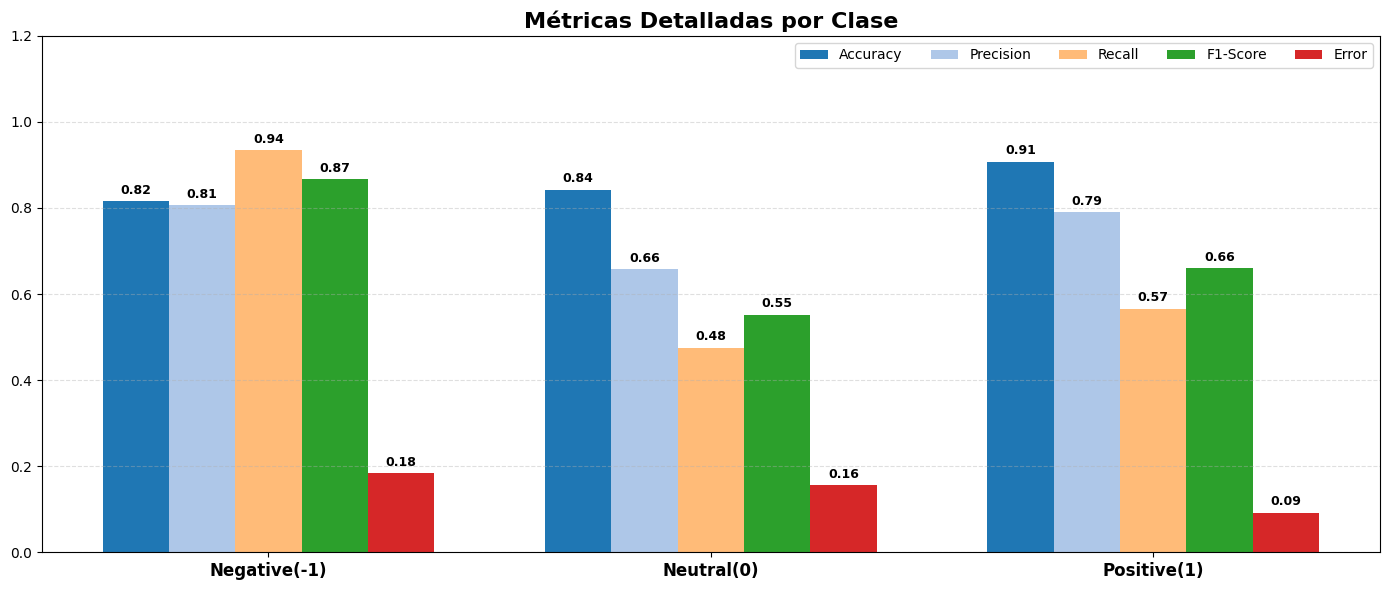

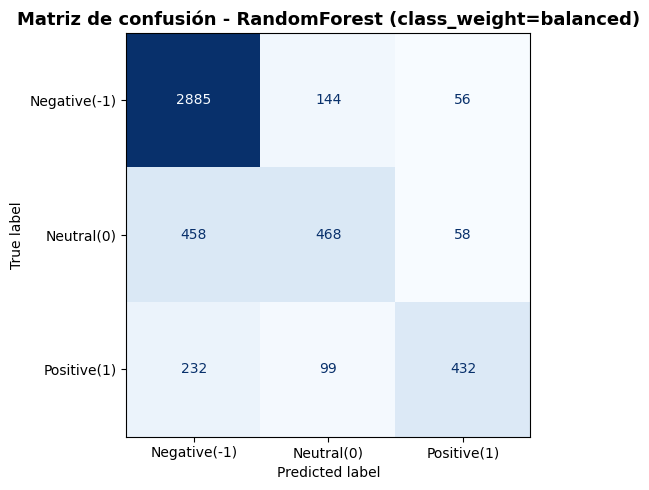

Accuracy multiclase: 0.7833
Macro F1-Score: 0.6929
Class -1: Precision: 0.81, Recall: 0.94, F1: 0.87, Acc: 0.82
Class 0: Precision: 0.66, Recall: 0.48, F1: 0.55, Acc: 0.84
Class 1: Precision: 0.79, Recall: 0.57, F1: 0.66, Acc: 0.91


In [18]:
# Reentrenamiento del mejor pipeline (lematización + CountVectorizer calibrado)
# usando class_weight='balanced' para mitigar el sesgo hacia la clase 'negative'.
# Reusamos X_tr_c / X_te_c, que son el set de entrenamiento/test ya lematizado
# y vectorizado en el Punto 3 (no hace falta re-calibrar el vectorizador).
rf_balanced = RandomForestClassifier(
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=10
)
rf_balanced_result = predecir_calcular(
    X_tr_c, y_train, X_te_c, y_test,
    rf_balanced, 'RandomForest (class_weight=balanced)'
)

### Análisis final

Comparando los 4 puntos con el mismo Random Forest y el mismo grid del CountVectorizer, el que mejor nos quedó fue el del **Punto 3 (CountVectorizer + Lematización verbal)**, con unigramas y bigramas y alrededor de 6 000 features. Lo que más ayuda es que la lematización junta las conjugaciones ("cancel / cancelled / cancelling / cancels") en un solo token, así varios tweets que hablan de lo mismo terminan en la misma columna de la matriz. Y a diferencia del Punto 2, aquí no se pierden las negaciones, así que los bigramas como `not_help` o `do_not` siguen apareciendo.

El peor fue el del **Punto 4 (Stopwords + Lematización)**, y la explicación es la misma del Punto 2: la lista por defecto de NLTK borra `not`, `no`, `nor`, `without`, `against`. Después de filtrar, "I am not happy" queda casi indistinguible de "I am happy". Lo poco que se gana en limpieza de vocabulario no compensa esa pérdida.

Mirando las matrices de confusión de los 4 modelos, el patrón es siempre el mismo: muchos tweets neutral y positive terminan clasificados como negative. Eso es por el desbalance del dataset (63 % negativos, 21 % neutros, 16 % positivos): el Random Forest por defecto no sabe del desbalance y se inclina por la clase mayoritaria. Para confirmarlo entrenamos el mejor pipeline con `class_weight='balanced'` y, como esperábamos, el accuracy global baja un poco pero el recall de neutral y positive sube — los errores se redistribuyen.

Si quisiéramos seguir mejorando esto, lo siguiente sería probar `class_weight='balanced'` de entrada, o algún tipo de balanceo en el train (SMOTE sobre la matriz sparse o undersampling de los negativos). Otra ruta sería cambiar la representación a TF-IDF y manejar las negaciones explícitamente, por ejemplo pegando "not good" en un solo token antes de vectorizar.